In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
config_dict = {
    "sim_params": {
        "is2d": 'true',
        "N": 16384 * 16384,
        "nx": 16384,
        "ny": 16384,
        "dx": 8.5e-8,          # 85 nm
        "z_detector": 4.0,     # 探测器位置 4.0 m
        "detector_size": 0.85e-3,       # 探测器 0.85 mm
        "detector_size_y": 0.85e-3,
        "detector_pixel_size_x": 2e-7, # 像素可调
        "detector_pixel_size_y": 2e-7,
        "chunk_size": 2*1024*1024*1024 // 16,
    },
    "use_disk_vector": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [4675, 4725],
        "x_range": [-1e-6, 1e-6],
        "y_range": [-1e-6, 1e-6],
        "z": 0.0,
        "nr_source_points": 10,
        "seed": 1,
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 1.0,            # 样品位于 1.0 m
            "pixel_size_x": 5e-8,      # 样品内部高分辨率
            "pixel_size_y": 5e-8,
            "pixel_size_z": 5e-8,
            "grid_path": "/mnt/d/rave-sim-main/rave-sim-main/grid/100um_half_hollow_millisphere.npy",
            "materials": [["H", 0.255]],
            "x_positions": [0],
            "y_positions": [0],
        },
    ],
}

print("N: ", config_dict["sim_params"]["N"])

N:  268435456


In [5]:
sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)

2026-06-08 21:35:24,631 INFO: Setting up simulation
2026-06-08 21:35:24,632 INFO: 2D mode: nx=16384, ny=16384, dx=8.500e-08, dy=8.500e-08, detector=(8.500e-04 x 8.500e-04) m
2026-06-08 21:36:10,719 INFO: 2D Nyquist check: dz=1.000e+00, x: Nx=16384, dx=8.500e-08, x_source=-1.000e-06 | y: Ny=16384, dy=8.500e-08, y_source=1.000e-06
2026-06-08 21:37:14,607 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260608_213610963237


In [6]:
computed = config.load(Path(sim_path / 'computed.yaml'))

#print("cutoff angles:", computed['cutoff_angles'])
#print("source points:", computed['source_points'])

In [7]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
#for i in range(20):
#    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)
for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

  0%|                                                                                            | 0/10 [00:00<?, ?it/s]

[2026-06-08 21:37:44.071] [info] Detector 2D mode
[2026-06-08 21:37:44.072] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260608_213610963237/00000000
[2026-06-08 21:37:44.072] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-08 21:37:44.072] [info] GPU memory required for wavefield: 2048 MB
[2026-06-08 21:37:44.781] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-08 21:38:09.258] [info]   Number of optical elements: 1
[2026-06-08 21:48:03.123] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-08 21:48:03.123] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-08 21:48:03.123] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08
[2026-06-08 21:48:03.796] [info] 2D Simulation finished in 681.030984077 seconds


 10%|████████                                                                         | 1/10 [10:49<1:37:27, 649.72s/it]

[2026-06-08 21:48:52.661] [info] Detector 2D mode
[2026-06-08 21:48:52.661] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260608_213610963237/00000001
[2026-06-08 21:48:52.661] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-08 21:48:52.661] [info] GPU memory required for wavefield: 2048 MB
[2026-06-08 21:48:53.095] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-08 21:49:08.444] [info]   Number of optical elements: 1
[2026-06-08 21:59:00.866] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-08 21:59:00.866] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-08 21:59:00.866] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08
[2026-06-08 21:59:01.578] [info] 2D Simulation finished in 668.879147974 seconds


 20%|████████████████▏                                                                | 2/10 [21:47<1:27:15, 654.44s/it]

...

 80%|████████████████████████████████████████████████████████████████▊                | 8/10 [1:33:51<23:40, 710.17s/it]

[2026-06-08 23:12:00.025] [info] Detector 2D mode
[2026-06-08 23:12:00.026] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260608_213610963237/00000008
[2026-06-08 23:12:00.026] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-08 23:12:00.026] [info] GPU memory required for wavefield: 2048 MB
[2026-06-08 23:11:57.998] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-08 23:12:13.091] [info]   Number of optical elements: 1
[2026-06-08 23:22:28.129] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-08 23:22:28.129] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-08 23:22:28.129] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08
[2026-06-08 23:22:28.775] [info] 2D Simulation finished in 678.882965379 seconds


 90%|████████████████████████████████████████████████████████████████████████▉        | 9/10 [1:45:14<11:41, 701.66s/it]

[2026-06-08 23:23:21.980] [info] Detector 2D mode
[2026-06-08 23:23:21.980] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260608_213610963237/00000009
[2026-06-08 23:23:21.980] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-08 23:23:21.980] [info] GPU memory required for wavefield: 2048 MB
[2026-06-08 23:23:22.344] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-08 23:23:47.683] [info]   Number of optical elements: 1
[2026-06-08 23:34:48.825] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-08 23:34:48.825] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-06-08 23:34:48.825] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08
[2026-06-08 23:34:49.695] [info] 2D Simulation finished in 687.715559327 seconds


100%|████████████████████████████████████████████████████████████████████████████████| 10/10 [1:57:35<00:00, 705.56s/it]


In [8]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1],wf.shape[2])

nr sources loaded: 10
nr phase steps: 1
nr detector pixels: 4250 4250


[[1.14367828e-14 7.75236232e-15 8.00019061e-15 ... 1.13915267e-14
  7.63246142e-15 7.73146602e-15]
 [7.81427111e-15 5.30633700e-15 5.48746144e-15 ... 7.84063163e-15
  5.18657798e-15 5.22493459e-15]
 [7.85236303e-15 5.34919729e-15 5.53702261e-15 ... 8.06545704e-15
  5.29963146e-15 5.30370908e-15]
 ...
 [1.16899508e-14 8.02089972e-15 8.30474978e-15 ... 1.23078665e-14
  8.08869963e-15 8.03769215e-15]
 [7.87198794e-15 5.36914365e-15 5.55452358e-15 ... 8.15808687e-15
  5.34982028e-15 5.33514163e-15]
 [7.88575561e-15 5.35787726e-15 5.53880985e-15 ... 7.97257226e-15
  5.24798405e-15 5.26492090e-15]]


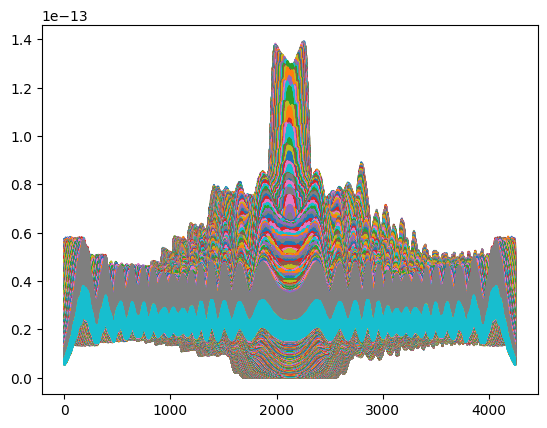

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
# print(detector_x)

In [13]:
from contextlib import redirect_stdout
with open('output_3d_test_DT_4700ev_260608.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            for j in range(len(wf[0][i])):
                print(wf[0][i][j])
            print('\n')

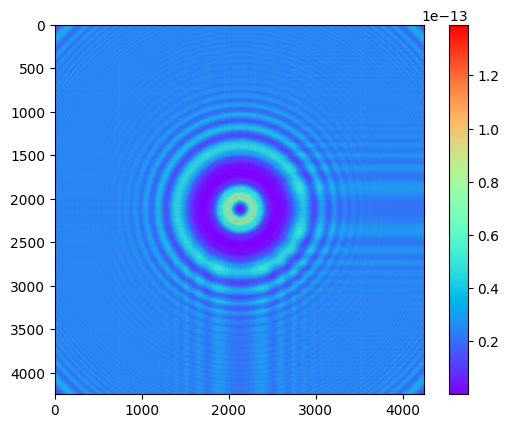

In [11]:
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()

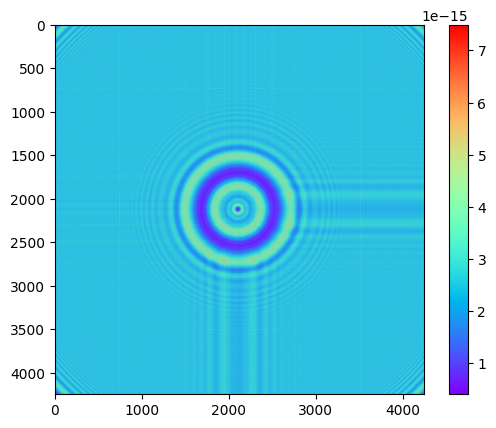

In [12]:
# one single shot
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()